# Does a Gartley "harmonic" pattern actually call reversals? 🦋
### A famous chart figure — five dots and a handful of Fibonacci ratios — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Fibonacci_forecasts%3F: Busted](https://img.shields.io/badge/Fibonacci_forecasts%3F-Busted-8b949e?style=flat-square)

Harmonic trading is one of the most seductive corners of technical analysis. You find a five-point zig-zag **X-A-B-C-D** on a chart, check that its legs retrace each other by the **Fibonacci numbers** (0.618, 0.786…), and — if they do — you declare point **D** a high-probability **reversal** and buy it. Whole courses, books and auto-scanners (Gartley, Bat, Butterfly, Crab) are built on this premise.

It *looks* uncanny on a hand-picked chart. But a pattern you label **after** the swings have happened, by choosing which five dots to connect and how loose a tolerance to accept, is the textbook setup for fooling yourself — especially on a market that drifts **up**. So we did the only fair thing: encode the Gartley **mechanically** (no eyeballing), fire the "buy the D-point" rule across five big indices over 21 years, and time the result against two honest baselines: **buying on random days**, and **swapping the Fibonacci ratios for random ones.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gartley_harmonic import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real Gartley cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 194, 'k': 4, 'fp_spy': '4cb5244f3990', 'h5': (5, 193, 20.3, 56, 1.15, 23.7, -3.4, 18.3, -0.13, 0.893), 'h10': (10, 193, 57.2, 67, 2.01, 39.6, 17.6, 55.2, 0.47, 0.641), 'h20': (20, 192, 123.9, 68, 3.05, 67.8, 56.2, 121.9, 1.09, 0.275), 'h60': (60, 189, 275.9, 70, 3.57, 75.2, 200.7, 273.9, 2.4, 0.017), 'per': [('SPY', 27, 132.8, 2.1, 57.5, 75.3), ('QQQ', 26, 137.2, 1.22, 125.9, 11.3), ('IWM', 45, 195.4, 1.72, 44.7, 150.7), ('DIA', 31, -24.8, -0.32, 38.1, -63.0), ('GLD', 65, 136.8, 2.0, 71.5, 65.3)], 'placebo20': (132.8, 0.443, 500), 'placebo60': (244.6, 0.591, 500), 'syn': [(0.0, 44, -6.8, 50, -0.1), (0.4, 53, 300.6, 100, 60.63)]}


real Gartley cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when a Gartley completes at **D**, do I make money? | **A little — and only at long horizons.** Over 60 days the D-point beats random days; over 5/10/20 days it's a coin flip. |
| Is that *the Fibonacci ratios'* doing? | **No.** Swap the 0.618 / 0.786 ratios for **random** ratios and you do **just as well**. The magic numbers add nothing. |
| So what's the 60-day edge, then? | **Generic dip-buying.** You bought a confirmed swing low and waited three months on a market that drifts up. The fork — sorry, the *fan* of Fibonacci ratios — is decoration. |
| Is it a tradable edge? | **Barely, and fragile.** One horizon, ~9 trades a year, geometry-agnostic. You'd capture the same thing more cheaply by just buying dips. |

> The Gartley is a vivid way to *describe* a swing after the fact. As a *forecast* — "these Fibonacci ratios mark the turn" — it's a **busted** premise: a real long-horizon dip-buy is in there, but the ratios aren't the reason.

## 1 · The claim

> *"Find five swing points X-A-B-C-D. If B retraces **0.618** of XA, C retraces 0.382–0.886 of AB, and D retraces **0.786** of XA, you have a **Gartley** — and price will reverse at D. Buy the bullish completion; the Fibonacci ratios forecast the turn."*

This codification is **H. M. Gartley** (1935) for the figure, **Larry Pesavento** (1997) and **Scott Carney** (1998) for the Fibonacci ratios. The whole harmonic zoo — Bat, Butterfly, Crab — is the same XABCD geometry with different magic numbers, and it's baked into TradingView, MetaTrader and Thinkorswim. So: do the ratios actually *forecast*?

## 2 · So what?

If specific Fibonacci ratios genuinely *forecast* reversals, it would be remarkable: five past dots and two decimals (0.618, 0.786) would predict a future turning point — a clean crack in market efficiency you could trade with a calculator. That's the dream harmonic trading sells.

But there are two traps. (1) A Gartley is labelled **by hand, after the swings happen**, on a market that drifts **up**, so *any* swing-low buy will look profitable. (2) The harmonic zoo offers **many** ratio templates — pick the one that fit in hindsight and you've data-mined a number. To separate the **ratios** from the **tide**, we (a) draw the pattern by a fixed mechanical rule with no hindsight, (b) compare it to buying on **random days**, and (c) swap the Fibonacci ratios for **random** ratios. We'll do all three.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **4 lower (higher) bars on each side** — a confirmed fractal, only known **4 bars later**, so we never label the pattern with future data.
2. **Scan for Gartleys by rule.** At every confirmed swing-low, search recent pivots for an ordered X-A-B-C-D whose ratios fit the Gartley grid — no eyeballing, no cherry-picking.
3. **Trade the lore.** When a bullish Gartley completes at **D**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baselines.** Do the same hold on **random days** (kills the drift), and rerun with **random ratios** instead of Fibonacci (kills the magic numbers). If the Gartley matters, it must beat *both*. *If it doesn't, the ratios are decoration* — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical Gartley even look like? Here's SPY with the detected bullish-Gartley D-points the rule would buy.

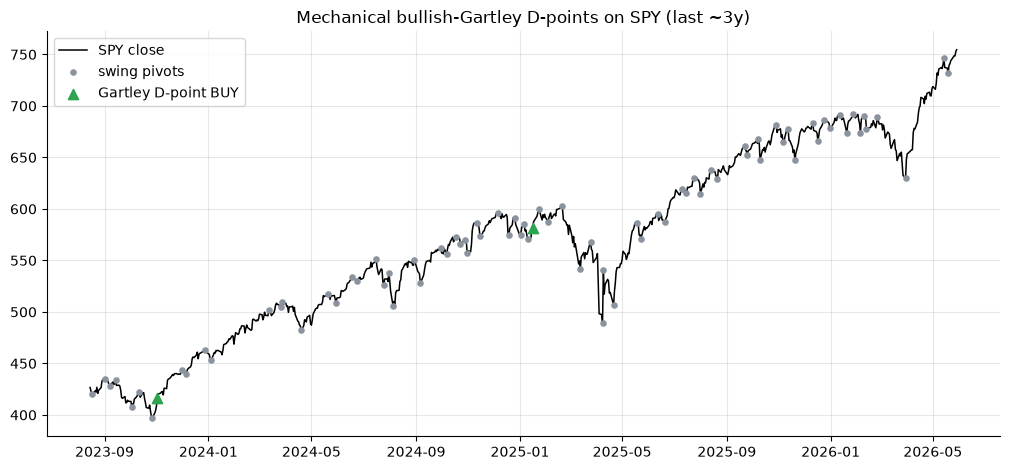

Gartley D-points in window: 2


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-700:]
    ent = st.detect_completions(cl, k=R['k'])
    ent = ent[ent >= seg.index[0]]
    piv = st._alternating(st.find_pivots(cl, k=R['k']))
    pv = piv[[ (cl.index[int(p)] >= seg.index[0]) for p in piv.index ]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter([cl.index[int(p)] for p in pv.index], pv['price'], c=GREY, s=14, zorder=4, label='swing pivots')
    ax.scatter(ent, cl.reindex(ent), c=GREEN, s=55, marker='^', zorder=5, label='Gartley D-point BUY')
    ax.set_title('Mechanical bullish-Gartley D-points on SPY (last ~3y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('Gartley D-points in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The detector picks out genuine five-point swings. The question is whether those green triangles are followed by bounces *because of the Fibonacci ratios*. **Let's race the D-point against random entries** at four horizons. Blue = buy the Gartley D; grey = buy on random days.

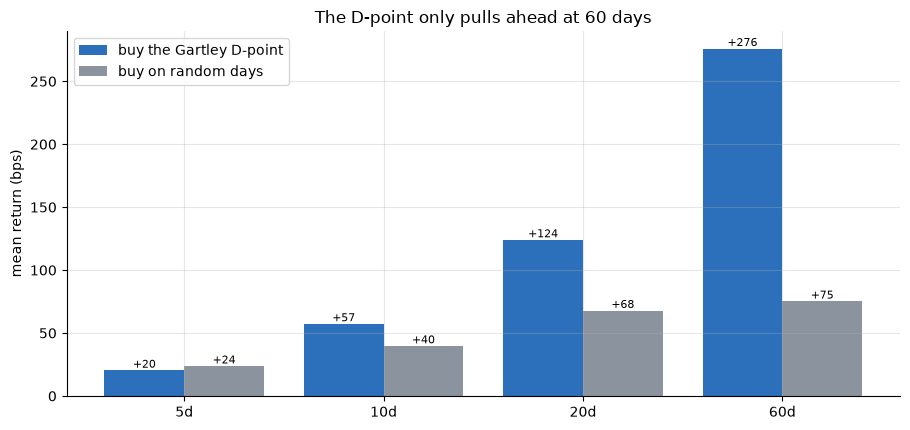

D-point: [20, 57, 124, 276]
random: [24, 40, 68, 75]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    dpt, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.detect_completions(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        dpt.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    dpt = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, dpt, .4, color='#2c6fbb', label='buy the Gartley D-point')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(dpt,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The D-point only pulls ahead at 60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('D-point:', [round(v) for v in dpt]); print('random:', [round(v) for v in rnd])

There's the headline. At 5/10/20 days the Gartley D-point is roughly a coin flip vs random (it's even *behind* at 5d). Only at **60 days** does it clearly pull ahead (**+276 bps** vs random's **+75**). So there *is* a long-horizon effect — but is it the *Fibonacci ratios*? Next test.

**The decisive check.** Keep the whole five-point machinery but **swap the Fibonacci ratios for random ones** (random targets in place of 0.618 / 0.786). If price really turns at *Fibonacci* D-points, the nonsense-ratio scans should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.ratio_grid_placebo(c, 20, k=R['k'], n_draws=200, seed=468)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo20'][0]; pval = R['placebo20'][1]
print(f'real Gartley D-point (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *random-ratio* grids do at least as well (p={pval:.2f}).')
print('=> the Fibonacci ratios are not doing the work.')

real Gartley D-point (SPY, 20d): +132.8 bps
... but 44% of *random-ratio* grids do at least as well (p=0.44).
=> the Fibonacci ratios are not doing the work.


Nearly half of the **random-ratio** grids match or beat the real Gartley (*p* = 0.44 at 20d, 0.59 at 60d). If price genuinely respected *these specific Fibonacci numbers*, a random ratio swap would collapse the result. It doesn't — because the long-horizon effect was never about the ratios.

## 5 · The verdict

- **Signal — Weak.** The D-point beats random days at **only one** horizon (60-day, *p* = 0.017); 5/10/20 days are a coin flip. A thin, long-only, long-horizon effect.
- **Tradability — Fragile.** One horizon, ~9 trades/year, and it survives the geometry scramble — it's generic swing-low dip-buying, capturable more cheaply.
- **"Do the Fibonacci ratios forecast the D-point turn?" — Busted.** Swap the ratios for random ones and the result barely moves (*p* ≈ 0.44–0.59). The magic numbers add nothing.

## 6 · Could you actually trade it?

Barely, and not as a *harmonic* strategy. The only thing the D-point has over a coin flip is a long-horizon dip-buy on a drifting market — which you'd get more simply by buying confirmed swing lows (or just holding the index). Drawing five-point Fibonacci forks adds labour and false precision, not edge. At ~9 trades a year on a single horizon, with the ratios demonstrably inert, there's nothing here to scale. As a forecasting tool the Gartley's defining feature — its Fibonacci ratios — does no measurable work.

## 7 · Going further 🚪

- **The rest of the zoo.** Bat (D = 0.886), Butterfly (1.272), Crab (1.618) are the same geometry with different magic numbers. The ratio-grid placebo predicts they'll all land the same way: drift + dip-buy in, Fibonacci out.
- **Tighter tolerances.** Squeeze the ratio bands and you get fewer trades and noisier stats, not a cleaner edge — the hallmark of a non-load-bearing parameter.
- **A real positive control.** The quants notebook plants a *genuine* Gartley bounce into a synthetic tape and shows the harness banks it (so the busted ratio result isn't a dead detector — it's an honest 'the numbers aren't it').

*Think the ratios forecast? Show the Fibonacci grid beating random ratio grids at **p < 0.05** on a real tape — then we'll talk.*